**Project 1**

**Setting up data:**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


features = [
    "matchId",
    "blueTeamControlWardsPlaced", "blueTeamWardsPlaced", "blueTeamTotalKills", "blueTeamDragonKills",
    "blueTeamHeraldKills", "blueTeamTowersDestroyed", "blueTeamInhibitorsDestroyed",
    "blueTeamTurretPlatesDestroyed", "blueTeamFirstBlood", "blueTeamMinionsKilled",
    "blueTeamJungleMinions", "blueTeamTotalGold", "blueTeamXp", "blueTeamTotalDamageToChamps",
    "redTeamControlWardsPlaced", "redTeamWardsPlaced", "redTeamTotalKills", "redTeamDragonKills",
    "redTeamHeraldKills", "redTeamTowersDestroyed", "redTeamInhibitorsDestroyed",
    "redTeamTurretPlatesDestroyed", "redTeamMinionsKilled", "redTeamJungleMinions",
    "redTeamTotalGold", "redTeamXp", "redTeamTotalDamageToChamps",
    "blueWin", "temp"
]

data = pd.read_csv('data.csv', names = features, na_values="?", skipinitialspace=True, skiprows=1)

data_without_classification = data.drop(columns=["matchId","blueWin", "temp"])
results_column = data["blueWin"]



X_train, X_test, y_train, y_test = train_test_split(
    data_without_classification, results_column,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("train:", len(X_train))
print("test:", len(X_test))

train: 19380
test: 4845


**Benchmark we will compare our model with**

Model Test Accuracy: 74.43%


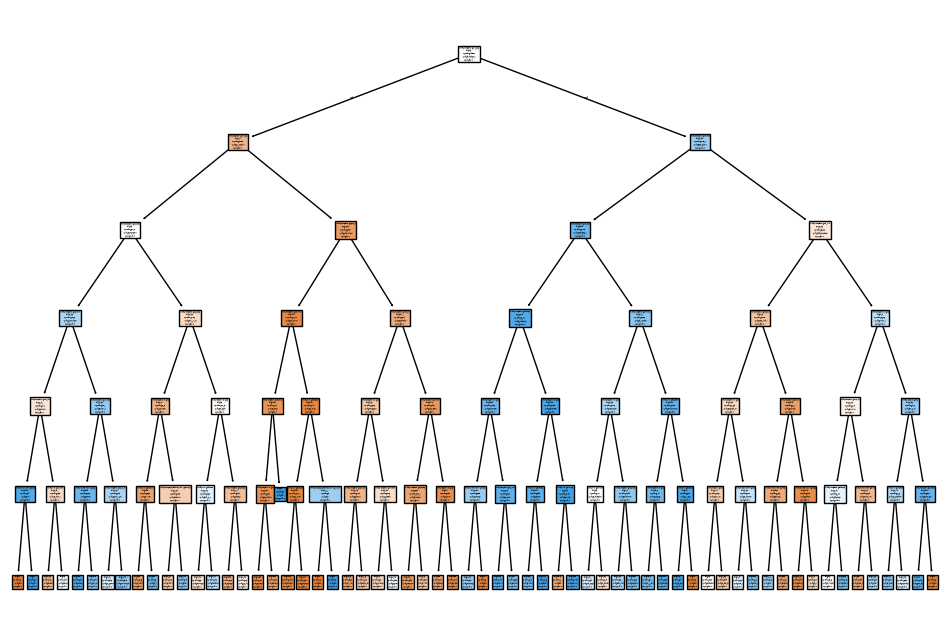

Train: 76.36%
Test:  74.43%


In [21]:
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Model Test Accuracy: {accuracy * 100:.2f}%")

plt.figure(figsize=(12, 8))
plot_tree(
    model, feature_names=X.columns, class_names=["red win", "blue win"],
    filled=True
)
plt.show()

print(f"Train: {model.score(X_train, y_train) * 100:.2f}%")
print(f"Test:  {model.score(X_test, y_test) * 100:.2f}%")

**Feature Engineering**